In [1]:
from pathlib import Path
import sys

cwd = Path.cwd()
if (cwd / "src").exists():
    project_root = cwd
elif (cwd.parent / "src").exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError("Could not locate project root containing 'src'.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


In [2]:
import numpy as np
import pandas as pd
from IPython.display import display
import statsmodels.api as sm


In [ ]:

from src.data.create_dataframes import processed_df_map

pd.set_option("display.float_format", "{:,.4f}".format)

DEFAULT_Y_COL_MAP = {
    "eur_df_processed": "EURUSD",
    "gbp_df_processed": "GBPUSD",
    "jpy_df_processed": "USDJPY",
    "chf_df_processed": "USDCHF",
    "cad_df_processed": "USDCAD",
    "aud_df_processed": "AUDUSD",
    "nzd_df_processed": "NZDUSD",
    "nok_df_processed": "USDNOK",
    "sek_df_processed": "USDSEK",
}

def latest_window_multivariate_ols(df: pd.DataFrame, y_col: str, window: int = 252):
    """Fit multivariate OLS on the most recent rolling window and return (summary, r2)."""
    if y_col not in df.columns:
        raise KeyError(f"{y_col} not found in dataframe columns.")

    window_df = df.tail(window).dropna()
    if len(window_df) < 2:
        raise ValueError("Not enough non-NaN rows in the latest rolling window.")

    y = window_df[y_col]
    X = window_df.drop(columns=[y_col])
    X_const = sm.add_constant(X, has_constant="add")

    model = sm.OLS(y, X_const).fit()
    r2 = model.rsquared

    betas = model.params.drop("const")
    pvals = model.pvalues.drop("const")
    signif_pct = (1 - pvals) * 100

    ranked_idx = betas.abs().sort_values(ascending=False).index
    betas = betas.reindex(ranked_idx)
    signif_pct = signif_pct.reindex(ranked_idx)

    summary = pd.DataFrame({
        "Driver Name": betas.index,
        "Beta Coefficient": betas.values,
        "Rank": np.arange(1, len(betas) + 1),
        "Significance %": signif_pct.values,
    })
    summary["Beta Coefficient"] = summary["Beta Coefficient"].round(4)
    summary["Significance %"] = summary["Significance %"].round(2)
    return summary, r2

def run_processed_df_regression(df_name: str, y_col: str | None = None, window: int = 252):
    """Convenience wrapper for processed_df_map by name."""
    if df_name not in processed_df_map:
        raise KeyError(f"{df_name} not found in processed_df_map.")

    if y_col is None:
        y_col = DEFAULT_Y_COL_MAP.get(df_name)
        if y_col is None:
            raise KeyError(f"No default y_col found for {df_name}.")

    summary, r2 = latest_window_multivariate_ols(processed_df_map[df_name], y_col, window=window)
    display(summary)
    print(f"Current 1Y Rolling R2: {r2:.4f}")
    return summary, r2




In [ ]:
sorted(processed_df_map.keys())


In [ ]:
# Example usage (default y_col is picked automatically)
run_processed_df_regression("nok_df_processed")


In [ ]:
def run_processed_df_regression_sig_only(
    df_name: str,
    y_col: str | None = None,
    window: int = 252,
    min_significance: float = 95.0,
):
    """Same as run_processed_df_regression but filters to >= min_significance."""
    summary, r2 = run_processed_df_regression(df_name, y_col=y_col, window=window)
    filtered = summary[summary["Significance %"] >= min_significance].reset_index(drop=True)
    display(filtered)
    print(f"Current 1Y Rolling R2: {r2:.4f}")
    return filtered, r2

run_processed_df_regression_sig_only("aud_df_processed")



In [ ]:
from src.data.create_dataframes import build_df2_map, frames, fx_newdf

# Assume you have frames and fx_newdf already loaded
df2_map = build_df2_map(frames, fx_newdf)

# To get the dataframe:
nok_df2 = df2_map["nok_df2"]
aud_df2 = df2_map["aud_df2"]
eur_df2 = df2_map["eur_df2"]


In [ ]:
aud_df2.tail()

In [ ]:
from src.data.build_ultimate_df import build_ultimate_df

ultimate_df = build_ultimate_df()
ultimate_df["aud"].tail()


In [ ]:
nok_ultimate_df = ultimate_df["nok"]
nok_ultimate_df

In [ ]:
sek_ultimate_df = ultimate_df["sek"]
sek_ultimate_df

In [ ]:
from src.data.build_ultimate_df import build_ultimate_df

ultimate_df = build_ultimate_df()

pd.set_option("display.float_format", "{:,.4f}".format)

DEFAULT_Y_COL_MAP = {
    "eur": "EURUSD",
    "gbp": "GBPUSD",
    "jpy": "USDJPY",
    "chf": "USDCHF",
    "cad": "USDCAD",
    "aud": "AUDUSD",
    "nzd": "NZDUSD",
    "nok": "USDNOK",
    "sek": "USDSEK",
}

def latest_window_multivariate_ols(df: pd.DataFrame, y_col: str, window: int = 252):
    """Fit multivariate OLS on the most recent rolling window and return (summary, r2)."""
    if y_col not in df.columns:
        raise KeyError(f"{y_col} not found in dataframe columns.")

    window_df = df.tail(window).dropna()
    if len(window_df) < 2:
        raise ValueError("Not enough non-NaN rows in the latest rolling window.")

    y = window_df[y_col]
    X = window_df.drop(columns=[y_col])
    X_const = sm.add_constant(X, has_constant="add")

    model = sm.OLS(y, X_const).fit()
    r2 = model.rsquared

    betas = model.params.drop("const")
    pvals = model.pvalues.drop("const")
    signif_pct = (1 - pvals) * 100

    ranked_idx = betas.abs().sort_values(ascending=False).index
    betas = betas.reindex(ranked_idx)
    signif_pct = signif_pct.reindex(ranked_idx)

    summary = pd.DataFrame({
        "Driver Name": betas.index,
        "Beta Coefficient": betas.values,
        "Rank": np.arange(1, len(betas) + 1),
        "Significance %": signif_pct.values,
    })
    summary["Beta Coefficient"] = summary["Beta Coefficient"].round(4)
    summary["Significance %"] = summary["Significance %"].round(2)
    return summary, r2

def run_processed_df_regression(df_name: str, y_col: str | None = None, window: int = 252):
    """Convenience wrapper for ultimate_df by name."""
    if df_name not in ultimate_df:
        raise KeyError(f"{df_name} not found in ultimate_df.")

    if y_col is None:
        y_col = DEFAULT_Y_COL_MAP.get(df_name)
        if y_col is None:
            raise KeyError(f"No default y_col found for {df_name}.")

    summary, r2 = latest_window_multivariate_ols(ultimate_df[df_name], y_col, window=window)
    display(summary)
    print(f"Current 1Y Rolling R2: {r2:.4f}")
    return summary, r2




In [ ]:
def run_processed_df_regression_sig_only(
    df_name: str,
    y_col: str | None = None,
    window: int = 252,
    min_significance: float = 95.0,
):
    """Same as run_processed_df_regression but filters to >= min_significance."""
    summary, r2 = run_processed_df_regression(df_name, y_col=y_col, window=window)
    filtered = summary[summary["Significance %"] >= min_significance].reset_index(drop=True)
    display(filtered)
    print(f"Current 1Y Rolling R2: {r2:.4f}")
    return filtered, r2




In [ ]:
run_processed_df_regression_sig_only("jpy")

In [ ]:
from src.ols_regressions import run_processed_df_regression_sig_only

# Now you can use the function:
run_processed_df_regression_sig_only("jpy")

In [ ]:
from src.ols_exBBDXY import run_processed_df_regression_sig_only

# Now you can use the function:
run_processed_df_regression_sig_only("aud")

In [ ]:
from src.rolling_univariate_ols import build_rolling_maps
from src.data.build_ultimate_df import build_ultimate_df

ultimate_df = build_ultimate_df()
betas_map, signif_map = build_rolling_maps(ultimate_df, window=250)

# Example
aud_betas = betas_map["aud"]
aud_signif = signif_map["aud"]


In [ ]:
# Example
aud_betas = betas_map["aud"]
aud_signif = signif_map["aud"]
aud_betas.tail()

In [ ]:
aud_signif.tail()

In [10]:
from src.data.build_ultimate_df import build_ultimate_df
from src.rolling_univariate_ols import build_rolling_maps
from src.top_drivers_history import build_top_drivers_history_map

ultimate_df = build_ultimate_df()
betas_map, signif_map = build_rolling_maps(ultimate_df, window=250)
top_map = build_top_drivers_history_map(betas_map, signif_map, min_significance=95.0, top_n=3)


KeyboardInterrupt: 

In [4]:
top_map["eur"].tail(5)     # or .head(), or just top_map["aud"]


,Driver 1 Name,Driver 2 Name,Driver 3 Name,Driver 1 Beta,Driver 2 Beta,Driver 3 Beta
2026-02-13,3m1m forward OIS,2y yield,6m1m forward OIS,3.643376,3.412974,2.561206
2026-02-16,3m1m forward OIS,2y yield,Real 2y yield,3.52361,3.311332,2.813285
2026-02-17,3m1m forward OIS,2y yield,Real 2y yield,3.591454,3.497596,2.94267
2026-02-18,3m1m forward OIS,2y yield,Real 2y yield,3.419381,3.22345,2.735765
NaT,3m1m forward OIS,2y yield,Real 2y yield,3.462153,3.237212,2.745604


In [11]:
from src.data.build_ultimate_df import build_ultimate_df
from src.rolling_univariate_ols import build_rolling_maps
from src.diversified_top_drivers_history import build_diversified_top_drivers_map

ultimate_df = build_ultimate_df()
betas_map, signif_map = build_rolling_maps(ultimate_df, window=250)
top_map = build_diversified_top_drivers_map(betas_map, signif_map, min_significance=95.0, top_n=3)


In [21]:
betas_map['eur'].tail(5)

,EMFX,2y yield,5y yield,10y yield,3m1m forward OIS,6m1m forward OIS,1y1m forward OIS,Real 2y yield,Local - S&P500,Local - Wilshire,...,Gold,Oil,Copper COMEX,Copper LME,MOVE Index,JPMVG71M Index,NG1 COMB Comdty,TZT1 Comdty,FN1 Comdty,VIX Index
2026-02-13,1.204876,3.412974,2.474436,1.843379,3.643376,2.561206,2.386037,2.355585,0.068165,0.067235,...,0.139959,-0.042102,0.037755,0.072071,0.003647,0.052287,0.073253,0.010477,0.004346,0.013502
2026-02-16,1.194670,3.311332,2.330508,1.640586,3.523610,2.497726,2.321019,2.813285,0.062087,0.061121,...,0.138547,-0.040137,0.036815,0.071008,NaN,0.050634,NaN,0.009850,0.004999,0.013437
2026-02-17,1.181349,3.497596,2.620046,1.879486,3.591454,2.536726,2.421018,2.942670,0.065130,0.064075,...,0.135865,-0.038903,0.037580,0.073342,0.003636,0.047015,0.074373,0.010562,0.004183,0.013700
2026-02-18,1.160527,3.223450,2.219343,1.299786,3.419381,2.383154,2.178189,2.735765,0.065438,0.064586,...,0.134027,-0.035822,0.032673,0.065925,NaN,0.042750,0.077596,0.013633,0.005106,0.013727
NaT,1.160483,3.237212,2.241829,1.311121,3.462153,2.402281,2.184452,2.745604,0.066307,0.065505,...,0.134022,-0.035805,0.032681,0.066505,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
ultimate_df['eur'].tail()

,EURUSD,BBDXY,EMFX,2y yield,5y yield,10y yield,3m1m forward OIS,6m1m forward OIS,1y1m forward OIS,Real 2y yield,...,Gold,Oil,Copper COMEX,Copper LME,MOVE Index,JPMVG71M Index,NG1 COMB Comdty,TZT1 Comdty,FN1 Comdty,VIX Index
2026-02-13,-0.025275,-0.034306,-0.02812,0.0243,0.0277,0.0258,0.01593,0.01824,0.02900,0.0483,...,2.405721,0.340061,0.290400,0.042708,70.10,7.73,3.243,32.500,76.25,20.60
2026-02-16,-0.143345,0.103941,0.00000,0.0050,0.0020,-0.0010,-0.00022,0.00385,0.01050,0.0000,...,-0.995811,1.319667,0.000000,-0.237064,NaN,7.31,NaN,30.903,72.55,21.20
2026-02-17,0.033747,0.008151,0.00000,-0.0299,-0.0282,-0.0255,0.00538,-0.03499,-0.03520,-0.0249,...,-2.313991,-1.807942,-2.740845,-1.813948,68.84,7.30,3.031,29.822,71.13,20.29
2026-02-18,-0.270293,0.220313,0.00000,-0.0142,-0.0194,-0.0141,-0.00572,-0.00504,-0.01237,-0.0312,...,2.433109,2.995329,2.493204,0.000000,NaN,7.30,2.974,31.410,76.41,18.98
NaT,0.000000,0.000000,0.00000,0.0000,0.0000,0.0000,0.00000,0.00000,0.00000,0.0000,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
top_map["nok"].tail(5)

,Driver 1 Name,Driver 1 Beta,Driver 2 Name,Driver 2 Beta,Driver 3 Name,Driver 3 Beta
2026-02-13,2y yield,2.718668,MSCI World - Dow Jones,-0.350038,BCOM Index,-0.342065
2026-02-16,2y yield,2.688309,MSCI World - Dow Jones,-0.345634,BCOM Index,-0.341161
2026-02-17,10y yield,2.850888,MSCI World - Dow Jones,-0.3411,BCOM Index,-0.338655
2026-02-18,10y yield,2.72449,BCOM Index,-0.333688,MSCI World ex-US,-0.327607
NaT,10y yield,2.71702,BCOM Index,-0.333718,MSCI World ex-US,-0.327332


In [20]:
top_map["eur"].tail(5)

,Driver 1 Name,Driver 1 Beta,Driver 2 Name,Driver 2 Beta,Driver 3 Name,Driver 3 Beta
2026-02-13,3m1m forward OIS,3.643376,MSCI World - S&P500,0.607264,Gold,0.139959
2026-02-16,3m1m forward OIS,3.52361,MSCI World - S&P500,0.593844,Gold,0.138547
2026-02-17,3m1m forward OIS,3.591454,MSCI World - S&P500,0.593482,Gold,0.135865
2026-02-18,3m1m forward OIS,3.419381,MSCI World - S&P500,0.578267,Gold,0.134027
NaT,3m1m forward OIS,3.462153,MSCI World - S&P500,0.585084,Gold,0.134022


In [8]:
# Standardized betas

from src.data.build_ultimate_df import build_ultimate_df
from src.data.standardize_rolling_drivers import build_standardized_df_map

ultimate_df = build_ultimate_df()
standardized_df_map = build_standardized_df_map(ultimate_df)

from src.rolling_univariate_ols import build_rolling_maps
from src.diversified_top_drivers_history import build_diversified_top_drivers_map

betas_mapz, signif_mapz = build_rolling_maps(standardized_df_map, window=250)
betas_raw, signif_raw = build_rolling_maps(ultimate_df, window=250)
top_mapz = build_diversified_top_drivers_map(
    betas_mapz,
    signif_mapz,
    min_significance=95.0,
    top_n=3,
    betas_raw_map=betas_raw,
)


In [18]:
top_mapz["eur"].tail(5)

,Driver 1 Name,Driver 1 Beta,Driver 2 Name,Driver 2 Beta,Driver 3 Name,Driver 3 Beta
2026-02-13,MSCI World - S&P500,0.243611,3m1m forward OIS,0.202353,Gold,0.187964
2026-02-16,MSCI World - S&P500,0.241303,3m1m forward OIS,0.195465,Gold,0.185753
2026-02-17,MSCI World - S&P500,0.240842,Real 2y yield,0.204011,Gold,0.182339
2026-02-18,MSCI World - S&P500,0.231172,3m1m forward OIS,0.189204,Gold,0.180948
NaT,MSCI World - S&P500,0.238725,3m1m forward OIS,0.19303,Gold,0.180959


In [12]:
standardized_df_map["aud"].tail()

,AUDUSD,BBDXY,Asia EMFX,2y yield,5y yield,10y yield,Real 2y yield,Local - S&P500,Local - Wilshire,Local - Dow Jones,...,Copper COMEX,Copper LME,MOVE Index,JPMVG71M Index,NG1 COMB Comdty,TZT1 Comdty,FN1 Comdty,VIX Index,SCOH6 COMB Comdty,IACA COMB Comdty
2026-02-13,-0.240062,0.015581,1.026597,0.058984,0.076997,-0.183496,0.495203,-1.008833,-1.078561,-1.121089,...,0.083724,-0.064943,-0.789345,-0.211250,-0.577263,-0.332994,-0.873357,0.292870,-0.219718,1.198981
2026-02-16,-0.014139,0.432392,-0.761889,-0.346283,-0.447615,-0.646475,0.017399,0.176255,0.174607,0.182499,...,-0.032995,-0.275785,NaN,-0.537875,NaN,-0.742163,-1.312619,0.406551,-0.242838,1.197637
2026-02-17,0.197768,0.096234,0.309649,-0.981477,-0.801781,-0.573183,-0.230685,0.122498,0.129348,0.154817,...,-1.153412,-1.471345,-0.848969,-0.540486,-0.872652,-1.022619,-1.478739,0.239002,-0.336398,1.120457
2026-02-18,-0.240198,0.751297,0.216462,-0.033628,0.062712,0.265434,-0.290546,-0.129264,-0.186094,-0.049330,...,1.001401,-0.084275,NaN,-0.535012,-0.947151,-0.595460,-0.832805,-0.004251,-0.432973,1.116604
NaT,0.000000,0.069238,0.060336,-0.053462,-0.047484,-0.028577,0.022097,0.021885,0.022732,0.015458,...,-0.026046,-0.079742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


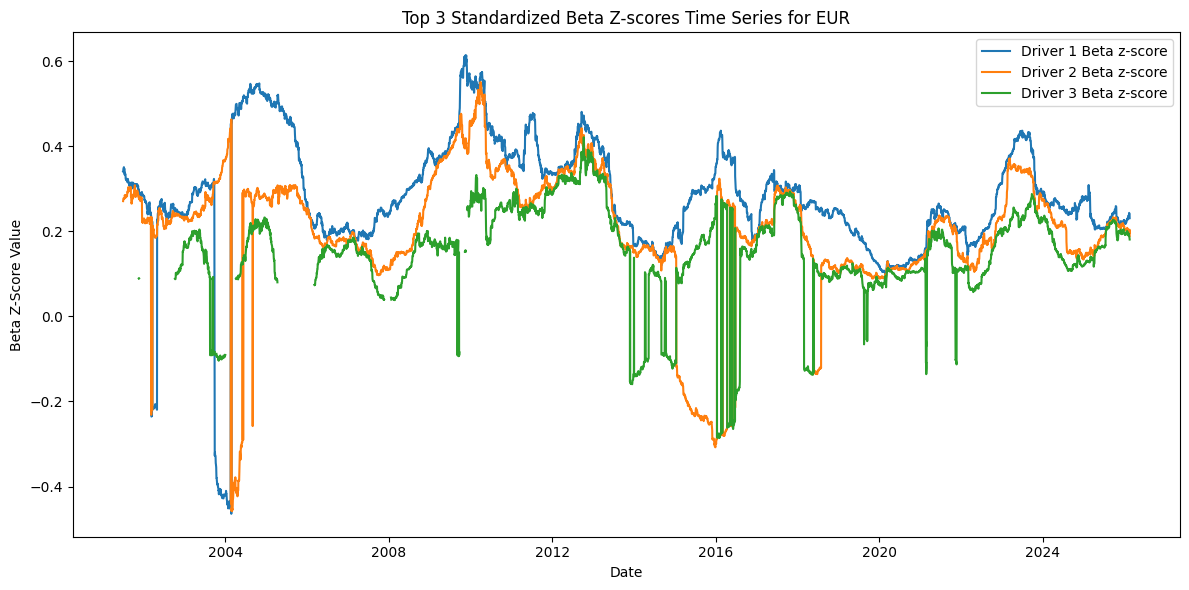

In [13]:
import matplotlib.pyplot as plt

# Choose the key you want to plot, e.g., "eur"
key = "eur"
df = top_mapz[key]

# Plot the three beta time series
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Driver 1 Beta Z"], label="Driver 1 Beta z-score")
plt.plot(df.index, df["Driver 2 Beta Z"], label="Driver 2 Beta z-score")
plt.plot(df.index, df["Driver 3 Beta Z"], label="Driver 3 Beta z-score")
plt.xlabel("Date")
plt.ylabel("Beta Z-Score Value")
plt.title(f"Top 3 Standardized Beta Z-scores Time Series for {key.upper()}")
plt.legend()
plt.tight_layout()
plt.show()


In [3]:
from src.data.build_ultimate_df import build_ultimate_df
from src.data.standardize_rolling_drivers import build_standardized_df_map
from src.rolling_univariate_ols import build_rolling_maps
from src.diversified_top_drivers_history import build_diversified_top_drivers_map


c:\Users\tilik\Cambridge\Year_1\D200\fx_valuation\fxvaluation_d200_am3483\src\data\load_excel_sheets.py:85: UserWarning: Unable to parse some dates in sheet 'FX', column 'USDNOK Curncy'; those rows will be NaT
  warnings.warn(
c:\Users\tilik\Cambridge\Year_1\D200\fx_valuation\fxvaluation_d200_am3483\src\data\load_excel_sheets.py:85: UserWarning: Unable to parse some dates in sheet 'FX', column 'USDKRW Curncy'; those rows will be NaT
  warnings.warn(
c:\Users\tilik\Cambridge\Year_1\D200\fx_valuation\fxvaluation_d200_am3483\src\data\load_excel_sheets.py:85: UserWarning: Unable to parse some dates in sheet 'FX', column 'USDSGD Curncy'; those rows will be NaT
  warnings.warn(
c:\Users\tilik\Cambridge\Year_1\D200\fx_valuation\fxvaluation_d200_am3483\src\data\load_excel_sheets.py:85: UserWarning: Unable to parse some dates in sheet 'FX', column 'USDTWD Curncy'; those rows will be NaT
  warnings.warn(
c:\Users\tilik\Cambridge\Year_1\D200\fx_valuation\fxvaluation_d200_am3483\src\data\load_exce

In [4]:
ultimate_df = build_ultimate_df()
standardized_df_map = build_standardized_df_map(ultimate_df)

betas_mapz, signif_mapz = build_rolling_maps(standardized_df_map, window=250)
betas_raw, signif_raw = build_rolling_maps(ultimate_df, window=250)

top_mapz = build_diversified_top_drivers_map(
    betas_mapz,
    signif_mapz,
    min_significance=95.0,
    top_n=3,
    betas_raw_map=betas_raw,
)


In [7]:
nok_df2_top = top_mapz["nok"]
nok_df2_top.tail(20)


,Driver 1 Name,Driver 2 Name,Driver 3 Name,Driver 1 Beta Z,Driver 2 Beta Z,Driver 3 Beta Z,Driver 1 Normal Beta,Driver 2 Normal Beta,Driver 3 Normal Beta
2026-01-23,MSCI World ex-US,BCOM Index,Real 2y yield,-0.288718,-0.283933,-0.195785,-0.306906,-0.364017,-1.245682
2026-01-26,MSCI World ex-US,BCOM Index,Real 2y yield,-0.286829,-0.281996,-0.201359,-0.305201,-0.36041,-1.281547
2026-01-27,MSCI World ex-US,BCOM Index,Real 2y yield,-0.29451,-0.280141,-0.203968,-0.312231,-0.358536,-1.295086
2026-01-28,MSCI World ex-US,BCOM Index,Real 2y yield,-0.294751,-0.276374,-0.203244,-0.312366,-0.353505,-1.290197
2026-01-29,MSCI World ex-US,BCOM Index,Real 2y yield,-0.289318,-0.275782,-0.20338,-0.307657,-0.352581,-1.28749
2026-01-30,MSCI World ex-US,BCOM Index,Real 2y yield,-0.291308,-0.276933,-0.206828,-0.309116,-0.351954,-1.302308
2026-02-02,MSCI World ex-US,BCOM Index,Real 2y yield,-0.293012,-0.271676,-0.205019,-0.310477,-0.33101,-1.29369
2026-02-03,MSCI World ex-US,BCOM Index,Real 2y yield,-0.295754,-0.278048,-0.203135,-0.312729,-0.336185,-1.282646
2026-02-04,MSCI World ex-US,BCOM Index,Real 2y yield,-0.299354,-0.276035,-0.202576,-0.314961,-0.333349,-1.27924
2026-02-05,MSCI World ex-US,BCOM Index,Real 2y yield,-0.30676,-0.280264,-0.186064,-0.321259,-0.338491,-1.205898


In [8]:
from src.rolling_multivariate_fair_value import (
    build_inputs,
    build_final_fair_value_map,
    plot_fair_value_bands,
)

ultimate_df, top_mapz = build_inputs(window=250)

final_fair_value_map, model_details_map = build_final_fair_value_map(
    ultimate_df,
    top_mapz,
    window=250,
    top_n=3,
    band_std=1.5,
)


In [9]:
eur_final_fair_value_df = final_fair_value_map["eur"]

eur_final_fair_value_df.tail()


,Actual_Price,Fair_Value,Lower_Bound,Upper_Bound
2026-02-13,-0.025275,0.281500,-0.309272,0.872271
2026-02-16,-0.143345,-0.126202,-0.715603,0.463199
2026-02-17,0.033747,-0.357967,-0.928243,0.212310
2026-02-18,-0.270293,0.009019,-0.557561,0.575599
NaT,0.000000,0.007732,-0.557907,0.573371


In [10]:
eur_model_details = model_details_map["eur"]

eur_model_details.tail()


,Intercept,Residual_Std,Driver 1 Name,Driver 2 Name,Driver 3 Name,Driver 1 Beta,Driver 2 Beta,Driver 3 Beta
2026-02-13,0.016713,0.393848,MSCI World - S&P500,3m1m forward OIS,Gold,0.392249,1.845093,0.128131
2026-02-16,0.015173,0.392934,MSCI World - S&P500,3m1m forward OIS,Gold,0.383283,1.818595,0.127739
2026-02-17,0.007071,0.380184,MSCI World - S&P500,Real 2y yield,Gold,0.393046,1.779647,0.120642
2026-02-18,0.006348,0.37772,MSCI World - S&P500,3m1m forward OIS,Gold,0.389545,1.674367,0.123956
NaT,0.007732,0.377093,MSCI World - S&P500,3m1m forward OIS,Gold,0.393677,1.70258,0.12359


In [12]:
plot_fair_value_bands(eur_final_fair_value_df)


[warn] No fair value data available for eur.
[warn] No fair value data available for aud.


In [3]:
from src.rolling_multivariate_fair_value import (
    build_inputs,
    build_final_fv_results,
    plot_stage2_diagnostics,
)

ultimate_df, top_mapz = build_inputs(window=250)

final_fv_results, fv_metadata_map = build_final_fv_results(
    ultimate_df,
    top_mapz,
    window=250,
    top_n=3,
)


c:\Users\tilik\Cambridge\Year_1\D200\fx_valuation\fxvaluation_d200_am3483\src\data\load_excel_sheets.py:85: UserWarning: Unable to parse some dates in sheet 'FX', column 'USDNOK Curncy'; those rows will be NaT
  warnings.warn(
c:\Users\tilik\Cambridge\Year_1\D200\fx_valuation\fxvaluation_d200_am3483\src\data\load_excel_sheets.py:85: UserWarning: Unable to parse some dates in sheet 'FX', column 'USDKRW Curncy'; those rows will be NaT
  warnings.warn(
c:\Users\tilik\Cambridge\Year_1\D200\fx_valuation\fxvaluation_d200_am3483\src\data\load_excel_sheets.py:85: UserWarning: Unable to parse some dates in sheet 'FX', column 'USDSGD Curncy'; those rows will be NaT
  warnings.warn(
c:\Users\tilik\Cambridge\Year_1\D200\fx_valuation\fxvaluation_d200_am3483\src\data\load_excel_sheets.py:85: UserWarning: Unable to parse some dates in sheet 'FX', column 'USDTWD Curncy'; those rows will be NaT
  warnings.warn(
c:\Users\tilik\Cambridge\Year_1\D200\fx_valuation\fxvaluation_d200_am3483\src\data\load_exce

In [4]:
final_fv_results["eur"].tail()


,Actual_Price,Fair_Value,Upper_Band,Lower_Band,Error_Gap,Adj_R2,RMSE,MAE,Drivers_Used_Count
2026-02-13,-0.025275,0.281500,1.067618,-0.504618,-0.306775,0.352058,0.393059,0.295674,3.0
2026-02-16,-0.143345,-0.126202,0.658093,-0.910497,-0.017143,0.344109,0.392148,0.294143,3.0
2026-02-17,0.033747,-0.357967,0.400880,-1.116813,0.391713,0.368815,0.379423,0.290395,3.0
2026-02-18,-0.270293,0.009019,0.762947,-0.744909,-0.279312,0.353442,0.376964,0.286361,3.0
NaT,0.000000,0.007732,0.760407,-0.744943,-0.007732,0.355541,0.376338,0.284902,3.0


In [5]:
fv_metadata_map["eur"].tail()


,Intercept,Drivers_Used,Window_Obs,R2,Adj_R2,RMSE,MAE,Driver 1 Name,Driver 2 Name,Driver 3 Name,Driver 1 Beta,Driver 2 Beta,Driver 3 Beta
2026-02-13,0.016713,"MSCI World - S&P500, 3m1m forward OIS, Gold",250,0.359864,0.352058,0.393059,0.295674,MSCI World - S&P500,3m1m forward OIS,Gold,0.392249,1.845093,0.128131
2026-02-16,0.015173,"MSCI World - S&P500, 3m1m forward OIS, Gold",250,0.352011,0.344109,0.392148,0.294143,MSCI World - S&P500,3m1m forward OIS,Gold,0.383283,1.818595,0.127739
2026-02-17,0.007071,"MSCI World - S&P500, Real 2y yield, Gold",250,0.37642,0.368815,0.379423,0.290395,MSCI World - S&P500,Real 2y yield,Gold,0.393046,1.779647,0.120642
2026-02-18,0.006348,"MSCI World - S&P500, 3m1m forward OIS, Gold",250,0.361232,0.353442,0.376964,0.286361,MSCI World - S&P500,3m1m forward OIS,Gold,0.389545,1.674367,0.123956
NaT,0.007732,"MSCI World - S&P500, 3m1m forward OIS, Gold",250,0.363306,0.355541,0.376338,0.284902,MSCI World - S&P500,3m1m forward OIS,Gold,0.393677,1.70258,0.12359


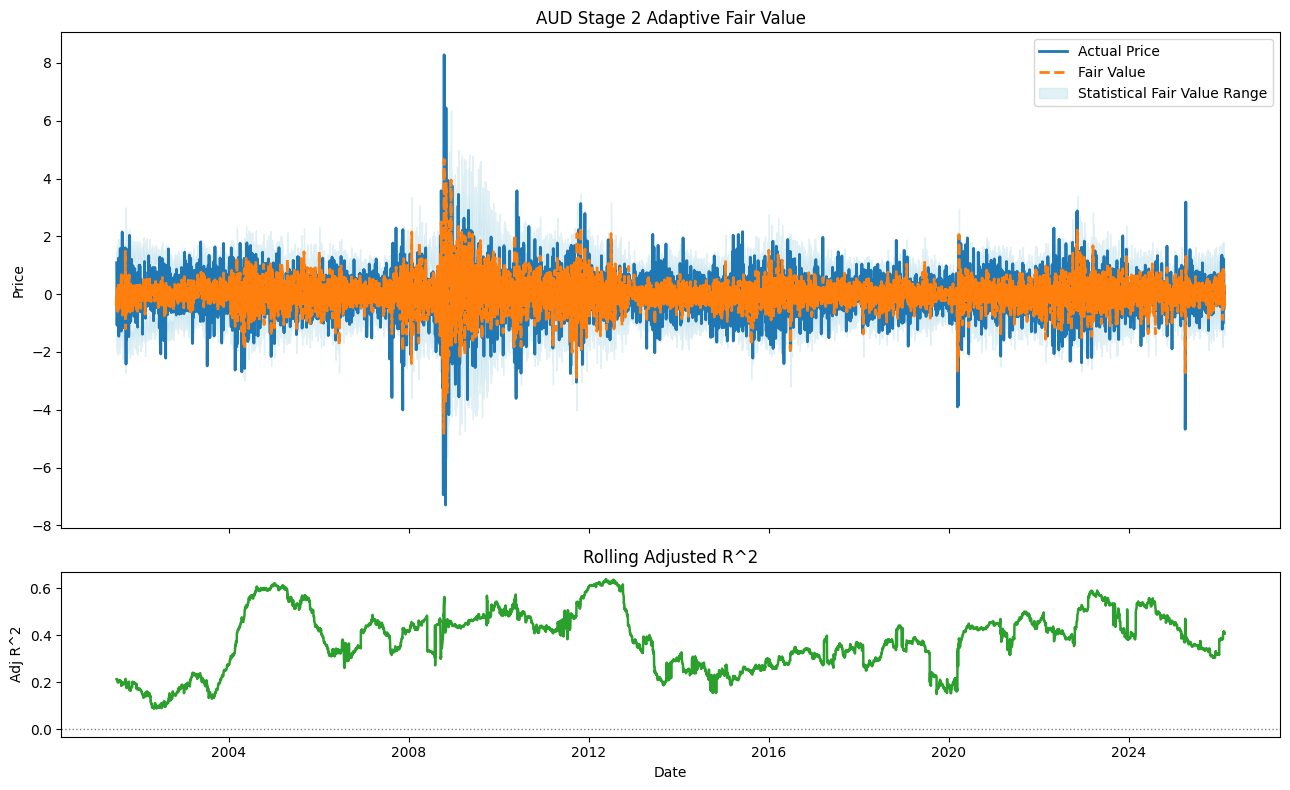

In [11]:
plot_stage2_diagnostics(final_fv_results, currency="aud")


In [8]:
from src.rolling_multivariate_fair_value import plot_stage2_diagnostics_plotly


ImportError: cannot import name 'plot_stage2_diagnostics_plotly' from 'src.rolling_multivariate_fair_value' (c:\Users\tilik\Cambridge\Year_1\D200\fx_valuation\fxvaluation_d200_am3483\src\rolling_multivariate_fair_value.py)

In [ ]:
fig = plot_stage2_diagnostics_plotly(
    final_fv_results,
    currency="eur",
    start_date="2022-01-01",
)
fig.show()
